In [12]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers
import matplotlib.pyplot as plt

# -----------------------------
# 1. Create Real Data
# -----------------------------
def get_real_data(batch_size):
    # Real data ~ Normal(mean=4, std=1)
    return np.random.normal(4, 1, (batch_size, 1))


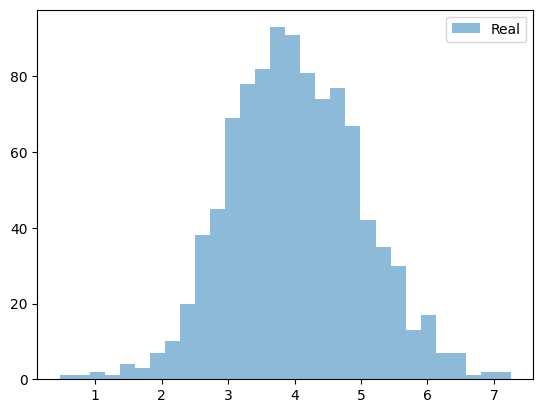

[[3.35], [1.41], [3.63], [4.32], [4.37]]


In [15]:
real_samples = get_real_data(1000)
plt.hist(real_samples, bins=30, alpha=0.5, label='Real')
plt.legend()
plt.show()

print(np.round(real_samples,2).tolist()[:5])

In [16]:
# -----------------------------
# 2. Build Generator
# -----------------------------
def build_generator():
    model = tf.keras.Sequential([
        layers.Dense(32, activation='relu', input_dim=1),
        layers.Dense(32, activation='relu'),
        layers.Dense(1)
    ])
    return model

# -----------------------------
# 3. Build Discriminator
# -----------------------------
def build_discriminator():
    model = tf.keras.Sequential([
        layers.Dense(32, activation='relu', input_dim=1),
        layers.Dense(32, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])
    return model





# -----------------------------
# 4. Initialize models
# -----------------------------
generator = build_generator()
discriminator = build_discriminator()

d_optimizer = tf.keras.optimizers.Adam(0.0005)
g_optimizer = tf.keras.optimizers.Adam(0.0003)

discriminator.compile(optimizer=d_optimizer, loss='binary_crossentropy')


# GAN model (freeze discriminator)
discriminator.trainable = False

gan_input = tf.keras.Input(shape=(1,))
fake = generator(gan_input)
gan_output = discriminator(fake)

gan = tf.keras.Model(gan_input, gan_output)
gan.compile(optimizer=g_optimizer, loss='binary_crossentropy')


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


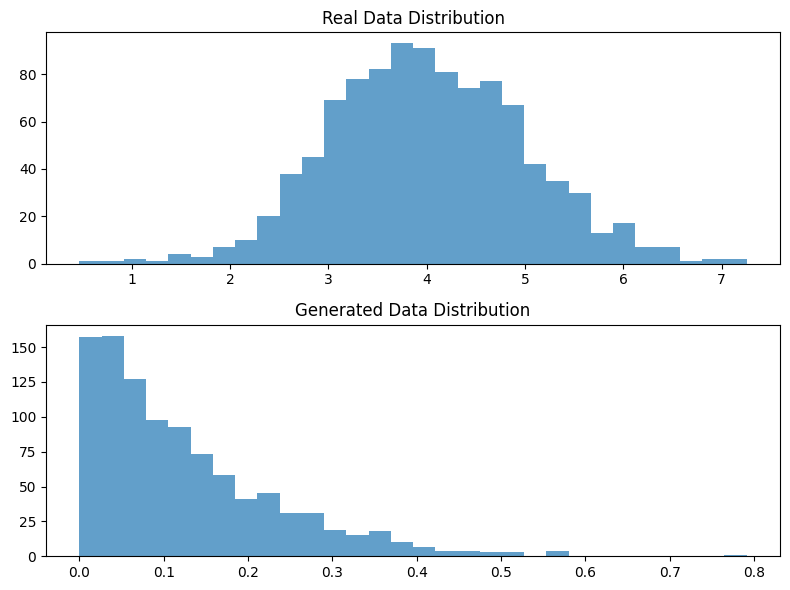

In [ ]:
# Before training
# -----------------------------
noise = np.random.normal(0, 1, (1000, 1))
generated_samples = generator.predict(noise, verbose=0)

plt.figure(figsize=(8, 6))

# Plot Real Data
plt.subplot(2, 1, 1)
plt.hist(real_samples, bins=30, alpha=0.7)
plt.title("Real Data Distribution")

# Plot Generated Data
plt.subplot(2, 1, 2)
plt.hist(generated_samples, bins=30, alpha=0.7)
plt.title("Generated Data Distribution")

plt.tight_layout()
plt.show()


In [18]:
print(real_samples[:5].round(2).tolist())
print(generated_samples[:5].round(2).tolist())


[[3.35], [1.41], [3.63], [4.32], [4.37]]
[[0.03999999910593033], [0.3100000023841858], [0.029999999329447746], [0.25999999046325684], [0.03999999910593033]]


In [19]:
# 5. Training Loop: Took 5 minutes on Google CPU

epochs = 2000
batch_size = 32

for epoch in range(epochs):

    # ---- Train Discriminator (more steps) ----
    for _ in range(2):

        real_data = get_real_data(batch_size)
        noise = np.random.normal(0, 1, (batch_size, 1))
        fake_data = generator.predict(noise, verbose=0)

        # Label smoothing
        real_labels = np.ones((batch_size, 1)) * 0.9
        fake_labels = np.zeros((batch_size, 1))

        X = np.vstack([real_data, fake_data])
        y = np.vstack([real_labels, fake_labels])

        discriminator.trainable = True
        d_loss = discriminator.train_on_batch(X, y)

    # ---- Train Generator ----
    noise = np.random.normal(0, 1, (batch_size, 1))
    y_gen = np.ones((batch_size, 1))  # want D(fake) → 1

    discriminator.trainable = False
    g_loss = gan.train_on_batch(noise, y_gen)

    # ---- Logging ----
    if epoch % 200 == 0:
        print(f"Epoch {epoch} | D Loss: {d_loss:.4f} | G Loss: {g_loss:.4f}")


Epoch 0 | D Loss: 0.5907 | G Loss: 0.6841
Epoch 200 | D Loss: 0.4132 | G Loss: 1.2572
Epoch 400 | D Loss: 0.5460 | G Loss: 1.1824
Epoch 600 | D Loss: 0.5909 | G Loss: 1.0796
Epoch 800 | D Loss: 0.6156 | G Loss: 0.9993
Epoch 1000 | D Loss: 0.6301 | G Loss: 0.9636
Epoch 1200 | D Loss: 0.6396 | G Loss: 0.9346
Epoch 1400 | D Loss: 0.6463 | G Loss: 0.9158
Epoch 1600 | D Loss: 0.6513 | G Loss: 0.9015
Epoch 1800 | D Loss: 0.6552 | G Loss: 0.8906


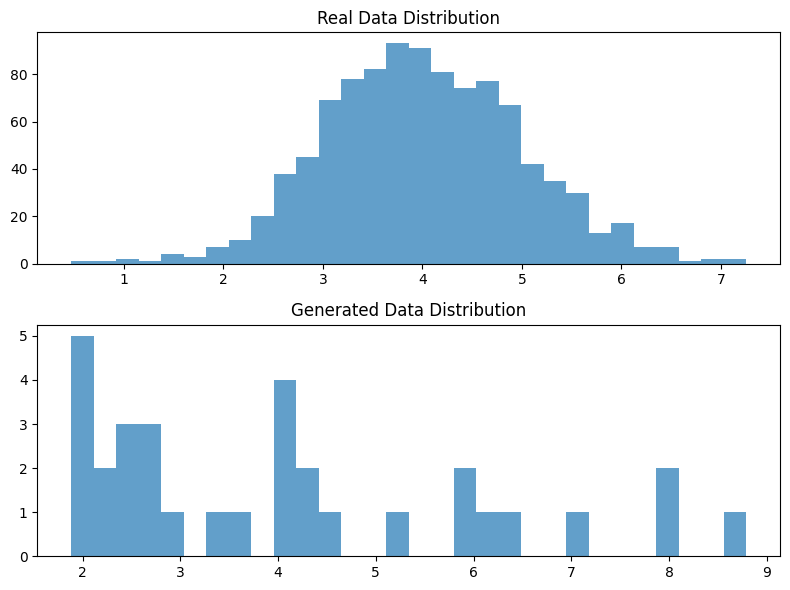

In [ ]:
# 6. After trining: Visualize Results (stacked)

generated_samples = generator.predict(noise, verbose=0)

plt.figure(figsize=(8, 6))

# Plot Real Data
plt.subplot(2, 1, 1)
plt.hist(real_samples, bins=30, alpha=0.7)
plt.title("Real Data Distribution")

# Plot Generated Data
plt.subplot(2, 1, 2)
plt.hist(generated_samples, bins=30, alpha=0.7)
plt.title("Generated Data Distribution")

plt.tight_layout()
plt.show()


In [22]:
print("Real Mean:", real_samples.mean())
print("Fake Mean:", generated_samples.mean())

print("Real Std:", real_samples.std())
print("Fake Std:", generated_samples.std())

Real Mean: 4.017534029379235
Fake Mean: 4.0602593
Real Std: 0.9877003596430832
Fake Std: 1.9782702
